**PHASE ONE** : LAODING THE DATASET AND DISPLAYING ITS FIRST FEW ROWS

In [2]:
import pandas as pd

# Load the TSV (tab-separated values) file
df = pd.read_csv("survey_phenotype_export_for_rti.tsv", sep="\t")

# Display basic info and first few rows
print("Shape:", df.shape)
print(df.head(2))
print(df.info())


Shape: (1196, 28)
  ParticipantID  Sample_Source  GENDER  AGE Phenotype  MECFS duration  \
0        PI-055            NaN  Female   44       CTL             NaN   
1        PI-055            NaN  Female   44       CTL             NaN   

  Study Site  Survey Day  Fatigue  Brain Fog  ...  Mean SSS  Baseline Sx  \
0        ITH          -1      1.0        3.0  ...  1.444444          NaN   
1        ITH           0      3.0        6.0  ...  2.111111          NaN   

   Pretest Sx  Recovery Time  Starting SSS  Adjusted Mean SSS  \
0         NaN            NaN           NaN                NaN   
1         Low            1.0           NaN                NaN   

   Normalized Mean SSS One Dose Kinetics  MECFS duration <4  \
0                  NaN               NaN                NaN   
1                  NaN               NaN                NaN   

  MECFS duration grouped  
0                    NaN  
1                    NaN  

[2 rows x 28 columns]
<class 'pandas.core.frame.DataFrame'>
Range

sep="\t" tells pandas it's a TSV file.

**PHASE TWO** : CHECK FOR MISSING VALUES & IMPUTATION

In [3]:


## ONE HOT ENCODING for the categorical columns (there's only 3 so it makes little sense to keep them)
# Columns to encode
cat_cols = ['Day Sx', 'Baseline Sx', 'Pretest Sx','GENDER']

# Check unique values first
for col in cat_cols:
    print(col, df[col].unique())

# One-hot encode (drop first to avoid dummy variable trap)
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


# Analyze missingness patterns
missing_percentage = (df.isna().sum() / len(df)) * 100
print("Missing value percentage per column:")
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

# Check if missingness is related to case/control status
if 'casecontrol' in df.columns:  # or whatever your target variable is called
    missing_by_group = df.groupby('casecontrol').apply(lambda x: x.isna().mean())
    print("\nMissingness by case/control status:")
    print(missing_by_group)

Day Sx ['Low' 'High' 'Mid' nan]
Baseline Sx [nan 'Low' 'Mid' 'High']
Pretest Sx [nan 'Low' 'Int' 'High']
GENDER ['Female' 'Male']
Missing value percentage per column:
Sample_Source             100.000000
One Dose Kinetics          51.505017
Normalized Mean SSS        51.505017
Adjusted Mean SSS          51.505017
Starting SSS               50.585284
MECFS duration grouped     46.906355
MECFS duration             46.906355
MECFS duration <4          46.906355
Recovery Time              11.789298
Mean SSS                    1.755853
Sore Throat                 0.836120
PEM                         0.752508
Tender Nodes                0.752508
Sleep Disturbance           0.668896
Brain Fog                   0.668896
Fatigue                     0.585284
Headache                    0.585284
Arthralgia                  0.585284
Myalgia                     0.501672
dtype: float64


## Imputation strategy:
-Some values are missing by structure, for example SSS and related variables are abscent in all controls so it makes no sense to impute it,

-Sample_Source is abscent in all rows so remove the feature altogether

-For other missing values: check if patient already has record (since some patients have more than one row) and replace with already existing value

-If not do KNN to replace missing

In [4]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

# Drop unnecessary columns
df = df.drop(columns=['Sample_Source','Study Site'])

# Putting MECFS duration to 0 for control cases
df['MECFS duration'] = df['MECFS duration'].fillna(0)
df.loc[df['Phenotype'] == 'CTL', 'MECFS duration'] = 0

# Impute symptoms
symptoms = ['Fatigue', 'Brain Fog', 'Sore Throat', 'Tender Nodes',
            'Myalgia', 'Arthralgia', 'Headache', 'Sleep Disturbance', 'PEM']

for col in symptoms:
    df[col] = df.groupby('ParticipantID')[col].transform(lambda x: x.fillna(x.median()))

# KNN imputation for all numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns
imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# Drop ME/CFS variables
mecfs_vars = ['Baseline Sx', 'Pretest Sx', 'Starting SSS',
              'Adjusted Mean SSS', 'Normalized Mean SSS', 'One Dose Kinetics',
              'MECFS duration <4', 'MECFS duration grouped']
df = df.drop(columns=[col for col in mecfs_vars if col in df.columns])

print(f"Final shape: {df.shape}")
print("No missing values remaining")

Final shape: (1196, 23)
No missing values remaining


In [62]:
# Save the cleaned dataset
df.to_csv('Clean_survey_phenotype.csv', index=False)
print("Dataset saved as 'ME_CFS_cleaned_dataset.csv'")


Dataset saved as 'ME_CFS_cleaned_dataset.csv'


In [ ]:
df = df.drop(columns=[col for col in derived_vars_to_drop if col in df.columns])
print(df.columns.tolist())

['ParticipantID', 'GENDER', 'AGE', 'Phenotype', 'Study Site', 'Survey Day', 'Fatigue', 'Brain Fog', 'Sore Throat', 'Tender Nodes', 'Myalgia', 'Arthralgia', 'Headache', 'Sleep Disturbance', 'PEM', 'Mean SSS', 'Recovery Time', 'Day Sx_Low', 'Day Sx_Mid', 'Baseline Sx_Low', 'Baseline Sx_Mid', 'Pretest Sx_Int', 'Pretest Sx_Low']


### NOTE:
#### features_to_keep = [
    'GENDER', 'AGE', 'Study Site', 'Survey Day',
    'Fatigue', 'Brain Fog', 'Sore Throat', 'Tender Nodes',
    'Myalgia', 'Arthralgia', 'Headache', 'Sleep Disturbance', 'PEM'
]
#### I dont want to lose the other columns yet but our analysis and model will mainly revolve around these variables

**PHASE THREE**: CORELATTION MATRIX

### NOTE: I will also delete mean_SSS though it is present in both controls and cases because it is pharmacokinetic and might overcomplicate and could be overfitting to this specific dataset

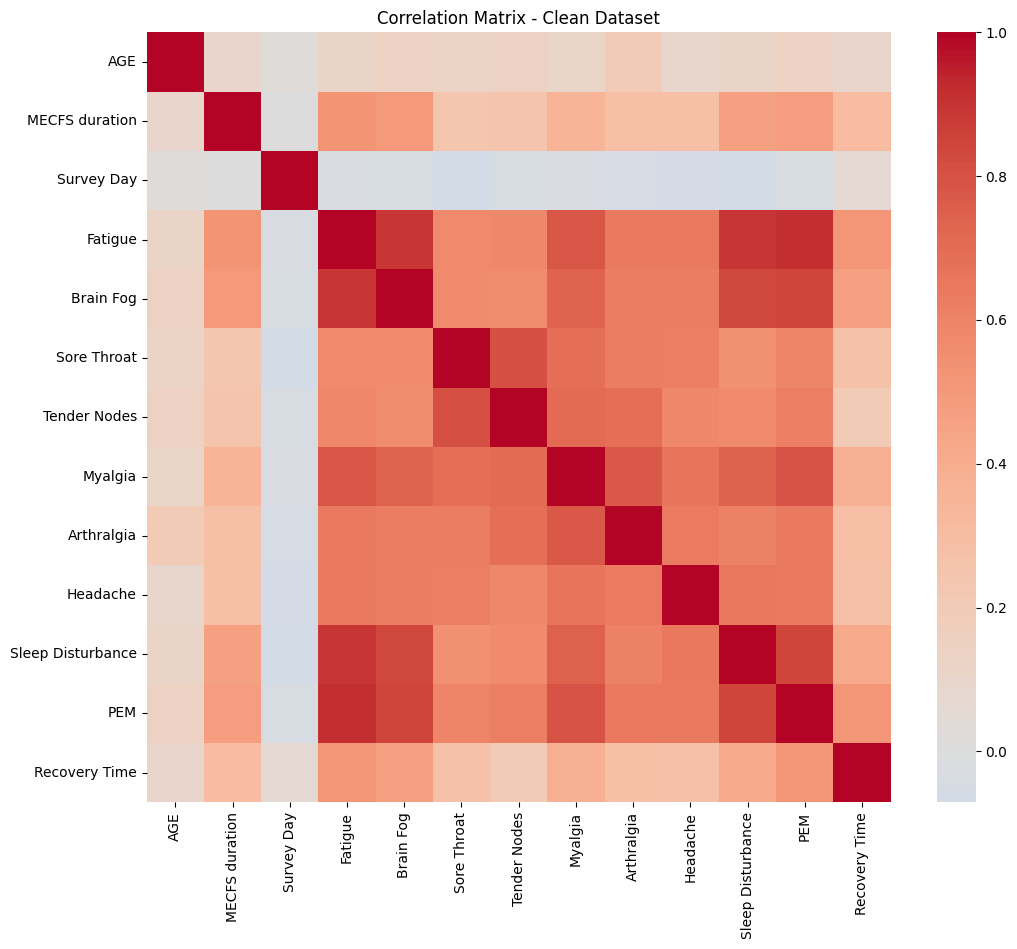

High correlations (>0.7):
Fatigue - Myalgia: 0.780
Fatigue - Sleep Disturbance: 0.888
Fatigue - PEM: 0.917
Brain Fog - Fatigue: 0.891
Brain Fog - Myalgia: 0.733
Brain Fog - Sleep Disturbance: 0.834
Brain Fog - PEM: 0.842
Sore Throat - Tender Nodes: 0.810
Myalgia - Tender Nodes: 0.705
Myalgia - Sleep Disturbance: 0.749
Myalgia - PEM: 0.797
Arthralgia - Myalgia: 0.776
PEM - Sleep Disturbance: 0.848


In [9]:
# Drop all ME/CFS specific variables
# print(df.columns.tolist())
# df = df.drop(columns=["Mean SSS"])
from matplotlib import pyplot as plt
import seaborn as sns

# Now do correlation matrix on clean dataset
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Clean Dataset')
plt.show()

# Check high correlations
high_corr = [(i, j, corr_matrix.loc[i, j]) for i in corr_matrix.columns
             for j in corr_matrix.columns if i < j and abs(corr_matrix.loc[i, j]) > 0.7]
print("High correlations (>0.7):")
for i, j, corr in high_corr:
    print(f"{i} - {j}: {corr:.3f}")

# PHASE THREE: Exploratory data analysis

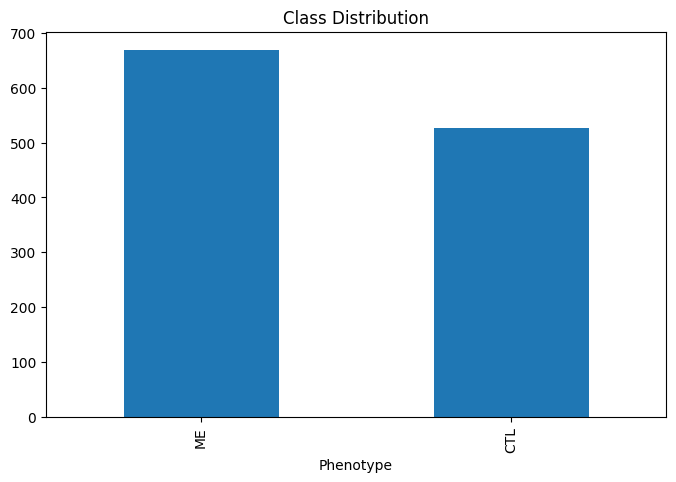

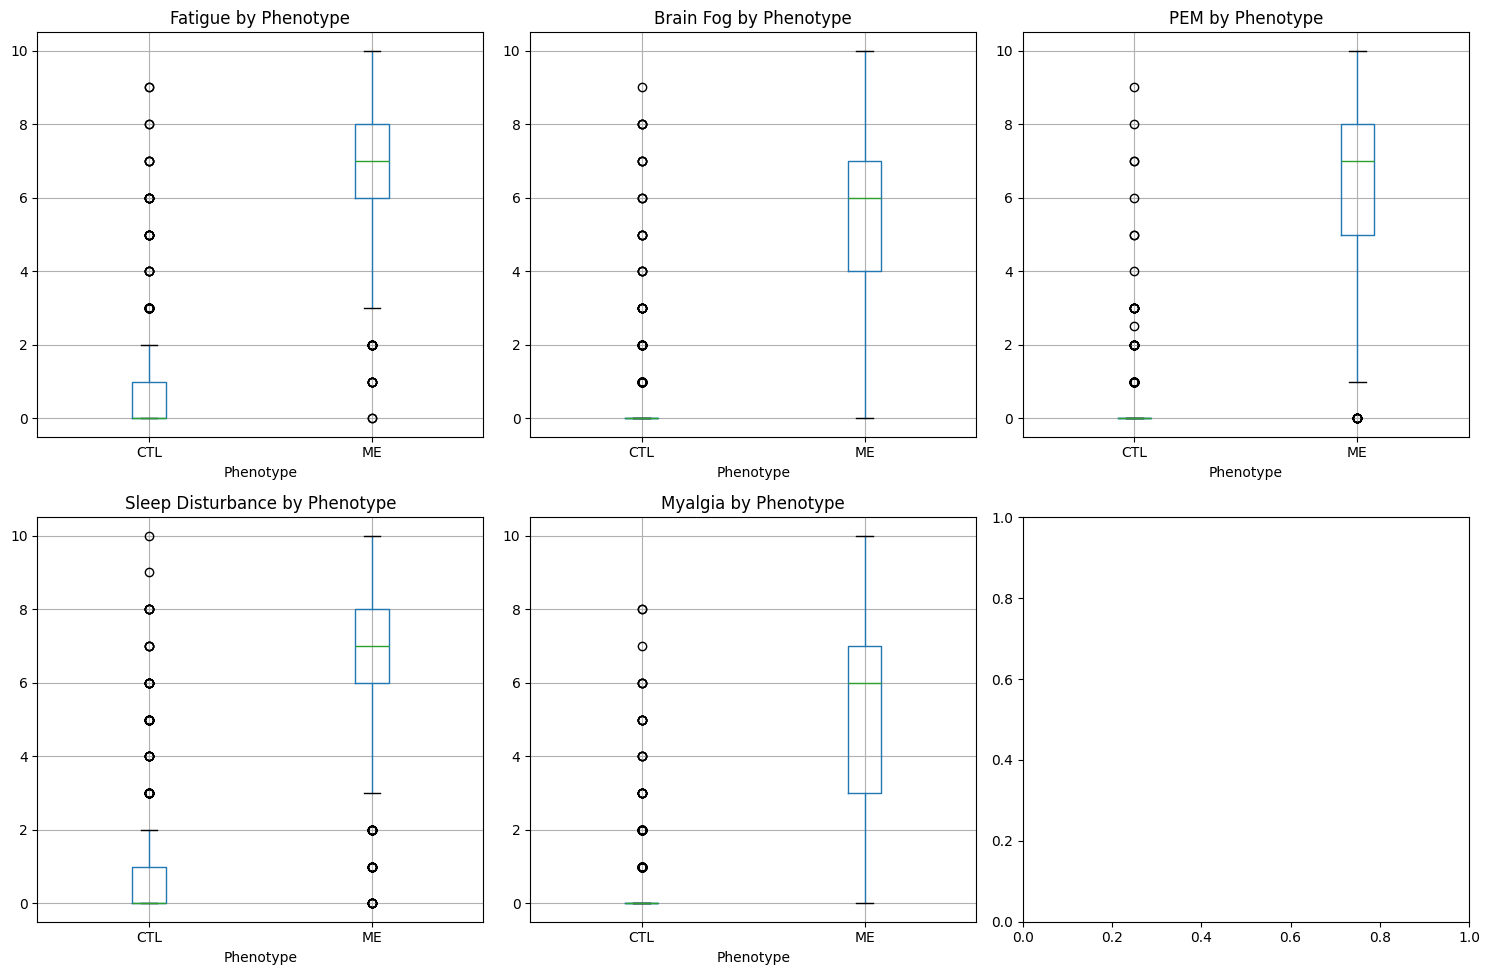

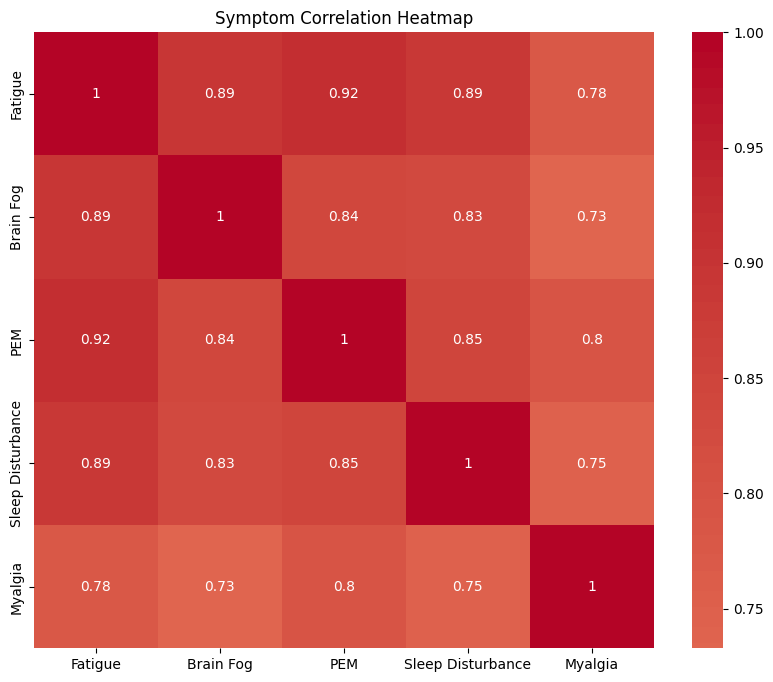

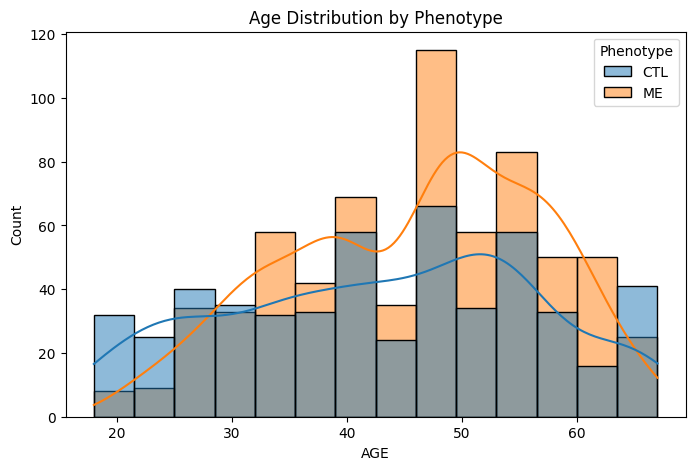

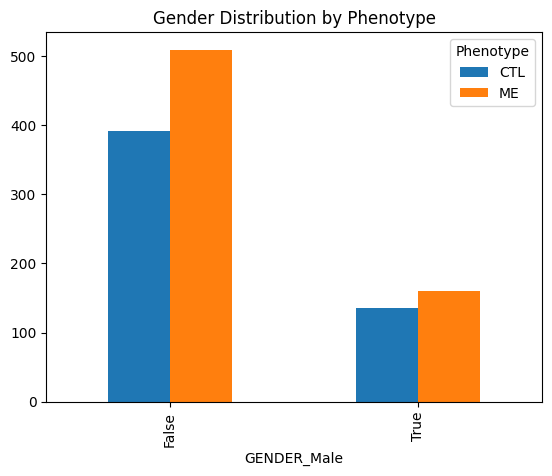

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Class distribution
plt.figure(figsize=(8, 5))
df['Phenotype'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.show()

# 2. Symptom distributions by phenotype
symptoms = ['Fatigue', 'Brain Fog', 'PEM', 'Sleep Disturbance', 'Myalgia']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, symptom in enumerate(symptoms):
    if i < len(axes):
        df.boxplot(column=symptom, by='Phenotype', ax=axes[i])
        axes[i].set_title(f'{symptom} by Phenotype')
plt.suptitle('')
plt.tight_layout()
plt.show()

# 3. Correlation heatmap (just symptoms)
plt.figure(figsize=(10, 8))
sns.heatmap(df[symptoms].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Symptom Correlation Heatmap')
plt.show()

# 4. Age distribution by phenotype
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='AGE', hue='Phenotype', kde=True)
plt.title('Age Distribution by Phenotype')
plt.show()

# 5. Gender distribution
pd.crosstab(df['GENDER_Male'], df['Phenotype']).plot(kind='bar')
plt.title('Gender Distribution by Phenotype')
plt.show()

# Overall a lot more females participated in the trial than males, this isnt conclusive to say that the proportion of males in MECFS is much lower since they could just be not doing the test

Participant repetition summary:
Total participants: 142
Total records: 1196
Average records per participant: 8.42


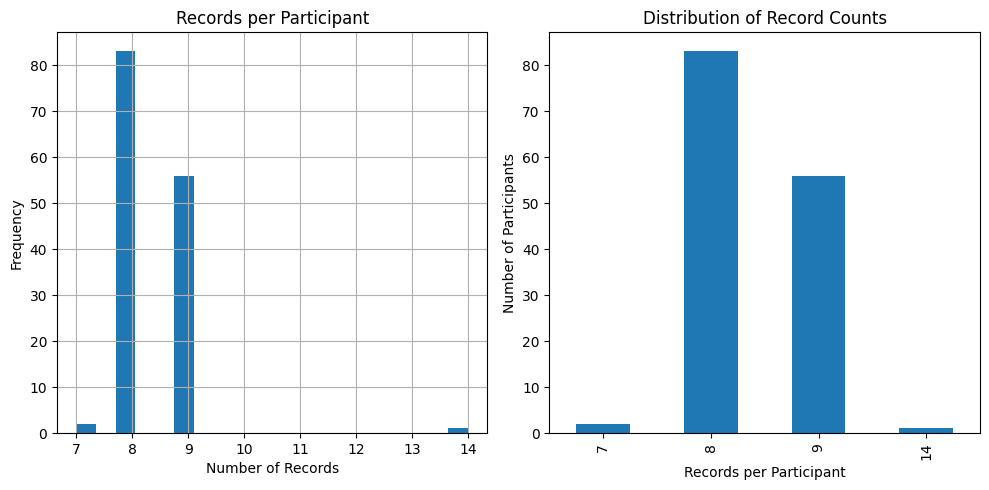

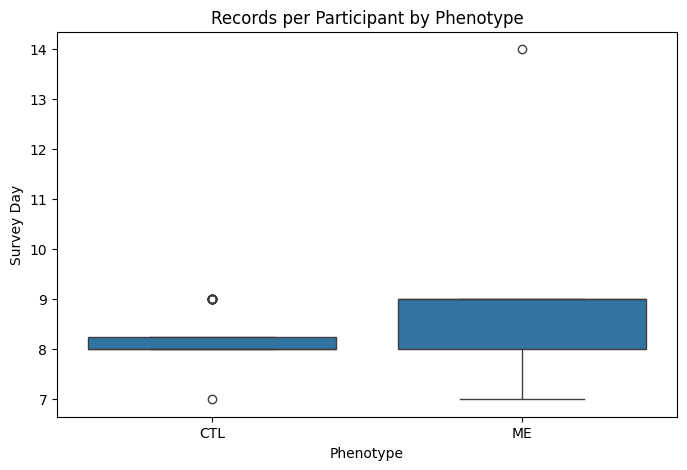

In [16]:
# Participant repetition analysis
participant_counts = df['ParticipantID'].value_counts()
print("Participant repetition summary:")
print(f"Total participants: {len(participant_counts)}")
print(f"Total records: {len(df)}")
print(f"Average records per participant: {len(df)/len(participant_counts):.2f}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
participant_counts.hist(bins=20)
plt.title('Records per Participant')
plt.xlabel('Number of Records')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
participant_counts.value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Record Counts')
plt.xlabel('Records per Participant')
plt.ylabel('Number of Participants')
plt.tight_layout()
plt.show()

# Check if repetition differs by phenotype
participant_summary = df.groupby('ParticipantID').agg({
    'Phenotype': 'first',
    'Survey Day': 'count'
}).reset_index()

plt.figure(figsize=(8, 5))
sns.boxplot(data=participant_summary, x='Phenotype', y='Survey Day')
plt.title('Records per Participant by Phenotype')
plt.show()

## ME CFS patients repeated the trial much more often than controls, with some guy so dedicated he repeated the experiment 14 times!!

## This could skew Cross validation results which means we have to use Grouped cross validation to make sure this person doesnt appear in training as well as testing for example
## This also calls for creation of groupped summary stats

## Potential for severity clustering, maybe the people who didnt redo the trial many times simply couldn't do so because of severity

# PHASE FOUR: FEATURE ENGINEERING & SELECTION

### -Using GroupShuffleSplit for the splitting of the data to make sure that none of the people who appear in training appear also in testing which could cause overfitting
### -Lasso selection kept all features due to high multicolinearity between the symptoms

### -For feature engineering the symptoms were combined by nature for example physical is a combination of Myalgia(muscle pain) arthalgia (joint pain) tender points which are all physical. neurological is combination of fatigue, brain fog, sleep disturbance

In [63]:
from sklearn.model_selection import GroupShuffleSplit

# Features and target (Drop MECFS duration cause it's obviously only present in cases not controls)
X = df.drop(columns=['Phenotype', 'ParticipantID', 'MECFS duration'])
y = df['Phenotype']
groups = df['ParticipantID']

# Split ensuring same person not in both sets
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Unique participants - Train: {X_train.index.nunique()}, Test: {X_test.index.nunique()}")


# Feature selection with Lasso to handle multicollinearity
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lasso for feature selection
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1)
lasso.fit(X_train_scaled, y_train)

# Get important features
feature_importance = abs(lasso.coef_[0])
important_features = X_train.columns[feature_importance > 0]
print(f"Selected {len(important_features)} features:")
print(important_features.tolist())

Train: 949, Test: 247
Unique participants - Train: 949, Test: 247
Selected 13 features:
['Survey Day', 'Fatigue', 'Sore Throat', 'Tender Nodes', 'Myalgia', 'Sleep Disturbance', 'PEM', 'Recovery Time', 'Baseline Sx_Mid', 'Pretest Sx_Int', 'Pretest Sx_Low', 'Total_Symptom_Score', 'High_Symptom_Persistence']


In [66]:

# 1. Symptom sum score
df['Total_Symptom_Score'] = df[['Fatigue','Brain Fog','PEM','Sleep Disturbance']].sum(axis=1)

# 2. Symptom clusters
df['Physical_Cluster'] = df[['Myalgia','Arthralgia','Tender Nodes']].mean(axis=1)
df['Neuro_Cluster'] = df[['Fatigue','Brain Fog','Sleep Disturbance']].mean(axis=1)

# 3. PEM-Recovery interaction
df['PEM_Recovery_Interaction'] = df['PEM'] * df['Recovery Time']

print("Added PEM-recovery interaction features")
print("Added: Total_Symptom_Score, Physical_Cluster, Neuro_Cluster")

# Save the dataset WITH engineered features
df.to_csv('FeatureEngineered_survey_phenotype_dataset.csv', index=False)
print("Dataset with engineered features saved as 'ME_CFS_with_engineered_features.csv'")

# Also save the selected important features list
important_features_df = pd.DataFrame({'selected_features': important_features})
important_features_df.to_csv('selected_features.csv', index=False)
print("Selected features list saved as 'selected_features.csv'")

# Save train/test splits for reproducibility
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print("Train/test splits saved for reproducibility")

Added PEM-recovery interaction features
Added: Total_Symptom_Score, Physical_Cluster, Neuro_Cluster
Dataset with engineered features saved as 'ME_CFS_with_engineered_features.csv'
Selected features list saved as 'selected_features.csv'
Train/test splits saved for reproducibility


# PHASE FIVE: MACHINE LEARNING

## Split into three phases:
### 1. trying with the original features, since the metrics here are near perfect this might be overfitting
### 2. try with only our feature engineered columns to maybe reduce overfitting
### 3. doing cross validation to confirm performance, misclassification analysis

In [56]:
from sklearn.model_selection import GridSearchCV, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Parameter grids
param_grids = {
    'RF': (RandomForestClassifier(), {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10]
    }),
    'XGB': (xgb.XGBClassifier(), {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.2]
    }),
    'SVM': (SVC(), {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    }),
    'GBC': (GradientBoostingClassifier(), {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 4, 5]
    }),
    'KNN': (KNeighborsClassifier(), {
        'n_neighbors': [3, 5, 7, 10, 15],
        'weights': ['uniform', 'distance']
    }),
    'LR': (LogisticRegression(), {
        'C': [0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    })
}

# Split data
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

# CASE 1: True original features (drop engineered columns)
engineered_cols = ['Total_Symptom_Score', 'Physical_Cluster', 'Neuro_Cluster',
                   'PEM_x_Recovery', 'High_Symptom_Persistence', 'Symptoms_Per_Recovery_Day','PEM_Recovery_Interaction']
X_orig_clean = X.drop(columns=[col for col in engineered_cols if col in X.columns])

X_train_orig, X_test_orig = X_orig_clean.iloc[train_idx], X_orig_clean.iloc[test_idx]

print("CASE 1: TRUE ORIGINAL FEATURES")
for name, (model, params) in param_grids.items():
    gs = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    gs.fit(X_train_orig, y_train_encoded)
    print(f"{name}: {gs.best_score_:.3f}")

# CASE 2: Engineered features ONLY
X_eng_only = pd.DataFrame()
X_eng_only['Total_Symptom_Score'] = X[['Fatigue','Brain Fog','PEM','Sleep Disturbance']].sum(axis=1)
X_eng_only['Physical_Cluster'] = X[['Myalgia','Arthralgia','Tender Nodes']].mean(axis=1)
X_eng_only['Neuro_Cluster'] = X[['Fatigue','Brain Fog','Sleep Disturbance']].mean(axis=1)
X_eng_only['PEM_x_Recovery'] = X['PEM'] * X['Recovery Time']

X_train_eng, X_test_eng = X_eng_only.iloc[train_idx], X_eng_only.iloc[test_idx]

print("\nCASE 2: ENGINEERED FEATURES ONLY")
for name, (model, params) in param_grids.items():
    gs = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    gs.fit(X_train_eng, y_train_encoded)
    print(f"{name}: {gs.best_score_:.3f}")

CASE 1: TRUE ORIGINAL FEATURES
RF: 0.983
XGB: 0.986
SVM: 0.983
GBC: 0.987
KNN: 0.954
LR: 0.976

CASE 2: ENGINEERED FEATURES ONLY
RF: 0.929
XGB: 0.936
SVM: 0.947
GBC: 0.927
KNN: 0.944
LR: 0.944


In [57]:
# Phase 03: Best model is GBC so we test overfitting and see other metrics

# Train best model (GBC)
best_gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3)
best_gbc.fit(X_train_orig, y_train_encoded)

# Final test evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = best_gbc.predict(X_test_orig)
y_proba = best_gbc.predict_proba(X_test_orig)[:, 1]

print("FINAL TEST RESULTS:")
print(f"Accuracy: {best_gbc.score(X_test_orig, y_test_encoded):.3f}")
print(f"ROC AUC: {roc_auc_score(y_test_encoded, y_proba):.3f}")
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred))

# Feature importance
print("\nTOP 10 FEATURES:")
importance_df = pd.DataFrame({
    'feature': X_train_orig.columns,
    'importance': best_gbc.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.head(10))

FINAL TEST RESULTS:
Accuracy: 0.968
ROC AUC: 1.000

Classification Report:
              precision    recall  f1-score   support

         CTL       1.00      0.93      0.96       114
          ME       0.94      1.00      0.97       133

    accuracy                           0.97       247
   macro avg       0.97      0.96      0.97       247
weighted avg       0.97      0.97      0.97       247


Confusion Matrix:
[[106   8]
 [  0 133]]

TOP 10 FEATURES:
            feature  importance
10              PEM    0.492918
2           Fatigue    0.303742
15  Baseline Sx_Mid    0.114812
3         Brain Fog    0.032826
11    Recovery Time    0.024408
16   Pretest Sx_Int    0.017466
1        Survey Day    0.004095
17   Pretest Sx_Low    0.003673
0               AGE    0.003655
8          Headache    0.000766


In [61]:
from sklearn.metrics import fbeta_score

# F-beta score with emphasis on false negatives (recall)
# Beta > 1 emphasizes recall (false negatives)
f2_score = fbeta_score(y_test_encoded, y_pred, beta=2)
f1_5_score = fbeta_score(y_test_encoded, y_pred, beta=1.5)

print("F-BETA SCORES (Emphasizing False Negatives):")
print(f"F2-score (beta=2): {f2_score:.3f}")  # Recall 2x more important than precision
print(f"F1.5-score (beta=1.5): {f1_5_score:.3f}")

# Since ME=1, CTL=0, false negatives are ME patients misclassified as controls
# These are the most costly errors in medical diagnosis
tn, fp, fn, tp = confusion_matrix(y_test_encoded, y_pred).ravel()
print(f"\nFalse Negatives (ME misclassified as CTL): {fn}")
print(f"False Positives (CTL misclassified as ME): {fp}")
print(f"Sensitivity/Recall: {tp/(tp+fn):.3f}")
print(f"Specificity: {tn/(tn+fp):.3f}")


## FBeta scores are really high so our model is doing great for false negatives!

F-BETA SCORES (Emphasizing False Negatives):
F2-score (beta=2): 0.988
F1.5-score (beta=1.5): 0.982

False Negatives (ME misclassified as CTL): 0
False Positives (CTL misclassified as ME): 8
Sensitivity/Recall: 1.000
Specificity: 0.930


In [59]:
from sklearn.inspection import permutation_importance
import numpy as np

# Permutation importance on TRUE datasets
print("PERMUTATION IMPORTANCE (95% CIs):")

# TRUE Original features
perm_orig = permutation_importance(best_gbc, X_test_orig, y_test_encoded, n_repeats=30, random_state=42)
print("\nTRUE Original Features:")
for i in np.argsort(perm_orig.importances_mean)[-5:][::-1]:
    mean = perm_orig.importances_mean[i]
    std = perm_orig.importances_std[i]
    print(f"  {X_train_orig.columns[i]}: {mean:.3f} ± {1.96*std:.3f}")

# TRUE Engineered features
perm_eng = permutation_importance(rf_eng, X_test_eng, y_test_encoded, n_repeats=30, random_state=42)
print("\nTRUE Engineered Features:")
for i in np.argsort(perm_eng.importances_mean)[::-1]:
    mean = perm_eng.importances_mean[i]
    std = perm_eng.importances_std[i]
    print(f"  {X_train_eng.columns[i]}: {mean:.3f} ± {1.96*std:.3f}")

PERMUTATION IMPORTANCE (95% CIs):

TRUE Original Features:
  Recovery Time: 0.161 ± 0.028
  Pretest Sx_Int: 0.128 ± 0.030
  Baseline Sx_Mid: 0.043 ± 0.020
  PEM: 0.013 ± 0.012
  Brain Fog: 0.002 ± 0.004

TRUE Engineered Features:
  PEM_x_Recovery: 0.270 ± 0.044
  Total_Symptom_Score: 0.153 ± 0.039
  Physical_Cluster: 0.002 ± 0.005
  Neuro_Cluster: 0.001 ± 0.006


Participant overlap: 0
